# **Factor Pool**

## Packages

In [1]:
import numpy as np
import pandas as pd

## Common Functions

In [2]:
# Rolling time series mean
def ts_mean(df,window):
    return df.rolling(window,min_periods=window).mean()

# x-ts_mean
def ts_av_diff(df, d):
    rolling_mean = df.rolling(d, min_periods=1).mean()
    return df - rolling_mean

# Rolling time series std
def ts_std_dev(df,window):
    return df.rolling(window,min_periods=window).std()

# Sum of days
def ts_sum(df,window):
    return df.rolling(window,min_periods=window).sum()

# Rolling z-score
def ts_zscore(df,window):
    df = df.astype(float)
    m = df.rolling(window).mean()
    s = df.rolling(window).std(ddof=1)
    return (df-m)/s
    
# Compute cross-section z-score
def zscore(df):
    mean = df.mean(axis=1)
    std = df.std(axis=1).replace(0,np.nan)
    z = df.sub(mean,axis=0).div(std,axis=0)
    return z.fillna(0.0)   

# Rank cross-sectionally according to values
def rank(df):
    return df.rank(axis=1,pct=True)

# Time series rank of the last observation in each window
def ts_rank(df,window):
    def rank_last(df):
        s = pd.Series(df)
        r = s.rank()
        return r.iloc[-1]/len(s)
    return df.rolling(window,min_periods=window).apply(rank_last,raw=False)

# Group cross-sectionally according to rank
def bucket(df,start,end,step):
    range = np.arange(start, end+1e-9, step)
    b = pd.DataFrame(np.digitize(df.values,range,right=True),index=df.index,columns=df.columns).astype('float')
    return b

# Forward gaps of rank bucket e.g. for five units with bucket(1,1,3,3,5) densify to (1,1,2,2,3)
def densify(df):
    out = df.copy()
    for time in df.index:
        vals = df.loc[time]
        uniq = pd.unique(vals.dropna())
        mapping = {g: k + 1 for k, g in enumerate(sorted(uniq))}
        out.loc[time] = vals.map(mapping)
    return out

# Shift (Delay) d days
def ts_delay(df,d):
    return df.shift(d)

# Subtract groupwise mean for each date
def group_neutralize(df,group):
    out = df.copy()
    for time in df.index:
        row = df.loc[time]
        g = group.loc[time]
    for grp in pd.unique(g.dropna()):
        mask = (g == grp)
        vals = row[mask]
        if len(vals) == 0:
            continue
        out.loc[time,mask] = vals - vals.mean()
    return out

# Scale x for each date to sum of x == 1
def scale(df):
    out = df.copy()
    denom = out.abs().sum(axis=1)
    denom[denom==0] = np.nan
    out = out.div(denom,axis=0)
    out = out.fillna(0.0)
    return out

# Trade when signal reaches entry/exit
def trade_when(entry,signal,exit):
    entry = entry.astype(bool)
    exit = exit.astype(bool)
    sig = signal.copy()

    pos = pd.DataFrame(0.0,index=signal.index,columns=signal.columns)
    prev = np.zeros(signal.shape[1],dtype=float)
    for i,time in enumerate(signal.index):
        e = entry.loc[time].values
        x = exit.loc[time].values
        s = sig.loc[time].values

        cur = prev.copy()
        cur[x] = 0.0
        mask_enter = e & (~x)
        cur[mask_enter] = s[mask_enter]

        pos.iloc[i,:] = cur
        prev = cur
    return pos

def trade_when_hold(cond_df, val_df):
    """
    Stateful trade_when for this alpha:
    - if cond is True  -> alpha_t = val_df
    - if cond is False -> alpha_t = alpha_{t-1}  (hold previous)
    - if no previous value (first day) and cond is False -> NaN
    All inputs are DataFrames with same shape.
    """
    cond = cond_df.reindex(val_df.index).fillna(False).astype(bool)
    vals = val_df.astype(float)

    out = pd.DataFrame(index=vals.index, columns=vals.columns, dtype=float)

    prev = np.full(vals.shape[1], np.nan, dtype=float)

    for i, date in enumerate(vals.index):
        c_row = cond.loc[date].values
        v_row = vals.loc[date].values.astype(float)

        cur = prev.copy()
        # where cond is true today, overwrite with today's values
        mask = c_row
        cur[mask] = v_row[mask]

        out.iloc[i, :] = cur
        prev = cur

    return out

# Hump smooth along time for each stock
def hump(df, hump):
    df = df.copy()
    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)

    # we’ll build it row by row, but handle "first valid" per column
    prev = np.full(len(df.columns), np.nan, dtype=float)

    for i, date in enumerate(df.index):
        raw = df.iloc[i, :].values.astype(float)

        # for names with no previous value but now a finite raw value,
        # treat this as their starting point (no hump limit on first obs)
        start_mask = np.isnan(prev) & np.isfinite(raw)
        prev[start_mask] = raw[start_mask]

        # if still NaN (never had a finite value), keep it NaN
        still_nan = np.isnan(prev) & ~np.isfinite(raw)
        raw[still_nan] = np.nan

        # for the rest, apply hump logic
        # use previous cross-section to set the per-day limit
        limit = hump * np.nansum(np.abs(prev))
        if not np.isfinite(limit) or limit == 0:
            cur = prev
        else:
            # any new NaNs in raw -> hold prev
            raw = np.where(np.isfinite(raw), raw, prev)
            delta = raw - prev
            step = np.where(np.abs(delta) <= limit, 0.0,
                            np.sign(delta) * limit)
            cur = prev + step

        out.iloc[i, :] = cur
        prev = cur

    return out

# Orthogonalize the alpha from b each day
def vector_neut(a,b):
    a = a.copy()
    b = b.copy()
    out = pd.DataFrame(index=a.index,columns=a.columns,dtype=float)
    for time in a.index:
        av = a.loc[time].values.astype(float)
        bv = b.loc[time].values.astype(float)
        mask = np.isinfinite(av) & np.isinfinite(bv) 
        if mask.sum() < 2 or np.all(bv[mask] == 0):
            out.loc[time] = av
            continue
        cov_ab = np.dot(av[mask],bv[mask])
        var_b = np.dot(bv[mask],bv[mask])
        beta = cov_ab / var_b
        adj = av - beta * bv
        out.loc[time] = adj
    return out

# For each date and stock, locate its industry and compute the weighted mean of the industry
def group_mean(df,weights,industry):
    out = df.copy()
    inds = industry.dropna()
    for time in df.index:
        row = df.loc[time]
        w = weights.loc[time]
        for ind in inds.unique():
            mask = (inds == ind)
            vals = row[mask]
            ws = w[mask]
            if len(vals) == 0:
                continue
            w_abs = np.abs(ws)
            w_sum = w_abs.sum()
            if w_sum == 0:
                mean_val = vals.mean()
            else:
                mean_val = (vals * w_abs/w_sum).sum()
            out.loc[time,mask] = mean_val
    return out

# Cross-sectional Cauchy quantile transform
def quantile_cauchy(df,eps=1e-6):
    u = df.rank(axis=1,pct=True)
    u = u.clip(eps,1-eps)
    return np.tan(np.pi*(u-0.5))

# Time-series Cauchy quantile of today's value vs last `window` days.
def ts_quantile_cauchy(df,window,eps=1e-6):
    df = df.astype(float)
    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)

    for col in df.columns:
        x = df[col].values
        n = len(x)
        res = np.full(n, np.nan, dtype=float)

        for i in range(window - 1, n):
            w = x[i - window + 1 : i + 1]

            # need finite last value and at least 1 finite in window
            if not np.isfinite(w[-1]):
                continue
            mask = np.isfinite(w)
            if mask.sum() == 0:
                continue

            w_valid = w[mask]
            last = w[-1]

            # percentile of today's value within window
            rank = (w_valid <= last).sum()
            u = rank / (mask.sum() + 1.0)   # (0,1) approx

            # clip to avoid infinities in tan()
            u = min(max(u, eps), 1 - eps)
            res[i] = np.tan(np.pi * (u - 0.5))

        out[col] = res

    return out

# Standard OLS on the last d points
# y, x: DataFrames [dates × tickers]
# Rettype: 0:Residual 3:Predicted Value 6:R^2
def ts_regression(y,x,window,lag,rettype):
    x_lag = x.shift(lag)
    out = pd.DataFrame(index=y.index, columns=y.columns, dtype=float)

    for col in y.columns:
        ys = y[col].values.astype(float)
        xs = x_lag[col].values.astype(float)
        n = len(ys)
        res = np.full(n, np.nan)
        for i in range(window - 1, n):
            # window indices [i-window+1, ..., i]
            y_win = ys[i - window + 1 : i + 1]
            x_win = xs[i - window + 1 : i + 1]
            mask = np.isfinite(y_win) & np.isfinite(x_win)
            if mask.sum() < 2:
                continue
            yw = y_win[mask]
            xw = x_win[mask]
            x_mean = xw.mean()
            y_mean = yw.mean()
            cov = ((xw - x_mean) * (yw - y_mean)).mean()
            var = ((xw - x_mean) ** 2).mean()
            if var == 0:
                beta = 0.0
            else:
                beta = cov / var
            alpha = y_mean - beta * x_mean
            y_hat = alpha + beta * xw
            if rettype == 0:
                res[i] = (yw-y_hat)[-1]
            elif rettype == 2:
                res[i] = beta
            elif rettype == 3:
                res[i] = y_hat[-1]
            elif rettype == 6:
                sse = ((yw - y_hat) ** 2).sum()
                sst = ((yw - y_mean) ** 2).sum()
                r2 = 1.0 - sse / sst if sst > 0 else 0.0
                res[i] = r2
            else:
                raise ValueError("rettype not implemented in ts_regression_core")
        out[col] = res
    return out

# Days Counter
def ts_step(df):
    n = len(df.index)
    step_vals = np.arange(1,n+1,dtype=float)
    step = pd.DataFrame(np.tile(step_vals[:,None],(1,df.shape[1])),index=df.index,columns=df.columns)
    return step

# Cross-Sectionally rank within the group on a given t
def group_rank(df,group):
    df, group = df.align(group, join="inner", axis=0) 
    df, group = df.align(group, join="inner", axis=1)
    out = df.copy().astype(float)
    for t in df.index:
        vals = df.loc[t]
        g = group.loc[t]
        for grp in pd.unique(g.dropna()):
            mask = (g == grp)
            sub = vals[mask]
            if len(sub) == 0:
                continue
            out.loc[t, mask] = sub.rank(method="average", pct=True)
    return out

# Cross-Sectionally Clip the values
def winsorize(df,std):
    out = df.copy().astype(float)
    for time in df.index:
        row = df.loc[time].values.astype(float)
        mask = np.isfinite(row)
        if mask.sum() == 0:
            continue
        vals = row[mask]
        mu = vals.mean()
        sigma = vals.std(ddof=1)
        if sigma == 0:
            continue
        lo = mu - std * sigma
        hi = mu + std * sigma
        row_clipped = np.clip(row, lo, hi)
        out.loc[time] = row_clipped
    return out

# Backward fill window of missing values
def ts_backfill(df,window):
    return df.astype(float).ffill(limit=window)

# Check whether there's min value in past d days
def ts_arg_min(df,window):
    df = df.astype(float)
    out = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for col in df.columns:
        vals = df[col].values
        n = len(vals)
        res = np.full(n, np.nan, dtype=float)
        for i in range(window - 1, n):
            window_vals = vals[i - window + 1 : i + 1]
            mask = np.isfinite(window_vals)
            if mask.sum() == 0:
                continue
            valid_vals = window_vals[mask]
            idxs = np.arange(window_vals.shape[0])[mask]
            # position (0..window-1) where min occurs
            pos_min = idxs[np.argmin(valid_vals)]
            # convert to 'days ago'
            res[i] = (window - 1) - pos_min
        out[col] = res
    return out

# Weighted Average across time series
def ts_decay_linear(df,window):
    def decay(x):
        x = np.array(x,float)
        x = np.nan_to_num(x,nan=0.0)
        n = len(x)
        w = np.arange(1,n+1)
        return np.dot(x,w)/w.sum()
    return df.rolling(window=window,min_periods=1).apply(decay,raw=True)

# If else Logic
def if_else(cond, a, b):
    """
    Vectorised if-else:
        cond : DataFrame or Series of booleans
        a, b : scalars, Series or DataFrames

    Returns something with the same shape/index/columns as `cond`.
    """
    # Normalize cond to a DataFrame for easier broadcasting
    if isinstance(cond, pd.Series):
        cond_df = cond.to_frame()
    else:
        cond_df = cond
    if np.isscalar(a) and np.isscalar(b):
        return pd.DataFrame(
            np.where(cond_df.values, a, b),
            index=cond_df.index,
            columns=cond_df.columns,
        )
    def _as_like(x):
        if isinstance(x, pd.DataFrame):
            return x.reindex_like(cond_df)
        elif isinstance(x, pd.Series):
            # broadcast series across columns
            return pd.DataFrame(
                np.repeat(x.values[:, None], cond_df.shape[1], axis=1),
                index=cond_df.index,
                columns=cond_df.columns,
            )
        else:  # scalar
            return pd.DataFrame(
                np.full(cond_df.shape, x),
                index=cond_df.index,
                columns=cond_df.columns,
            )
    A = _as_like(a)
    B = _as_like(b)
    out = A.where(cond_df, other=B)
    if isinstance(cond, pd.Series):
        return out.iloc[:, 0]
    return out

# **Options Dataset**

# Alpha1
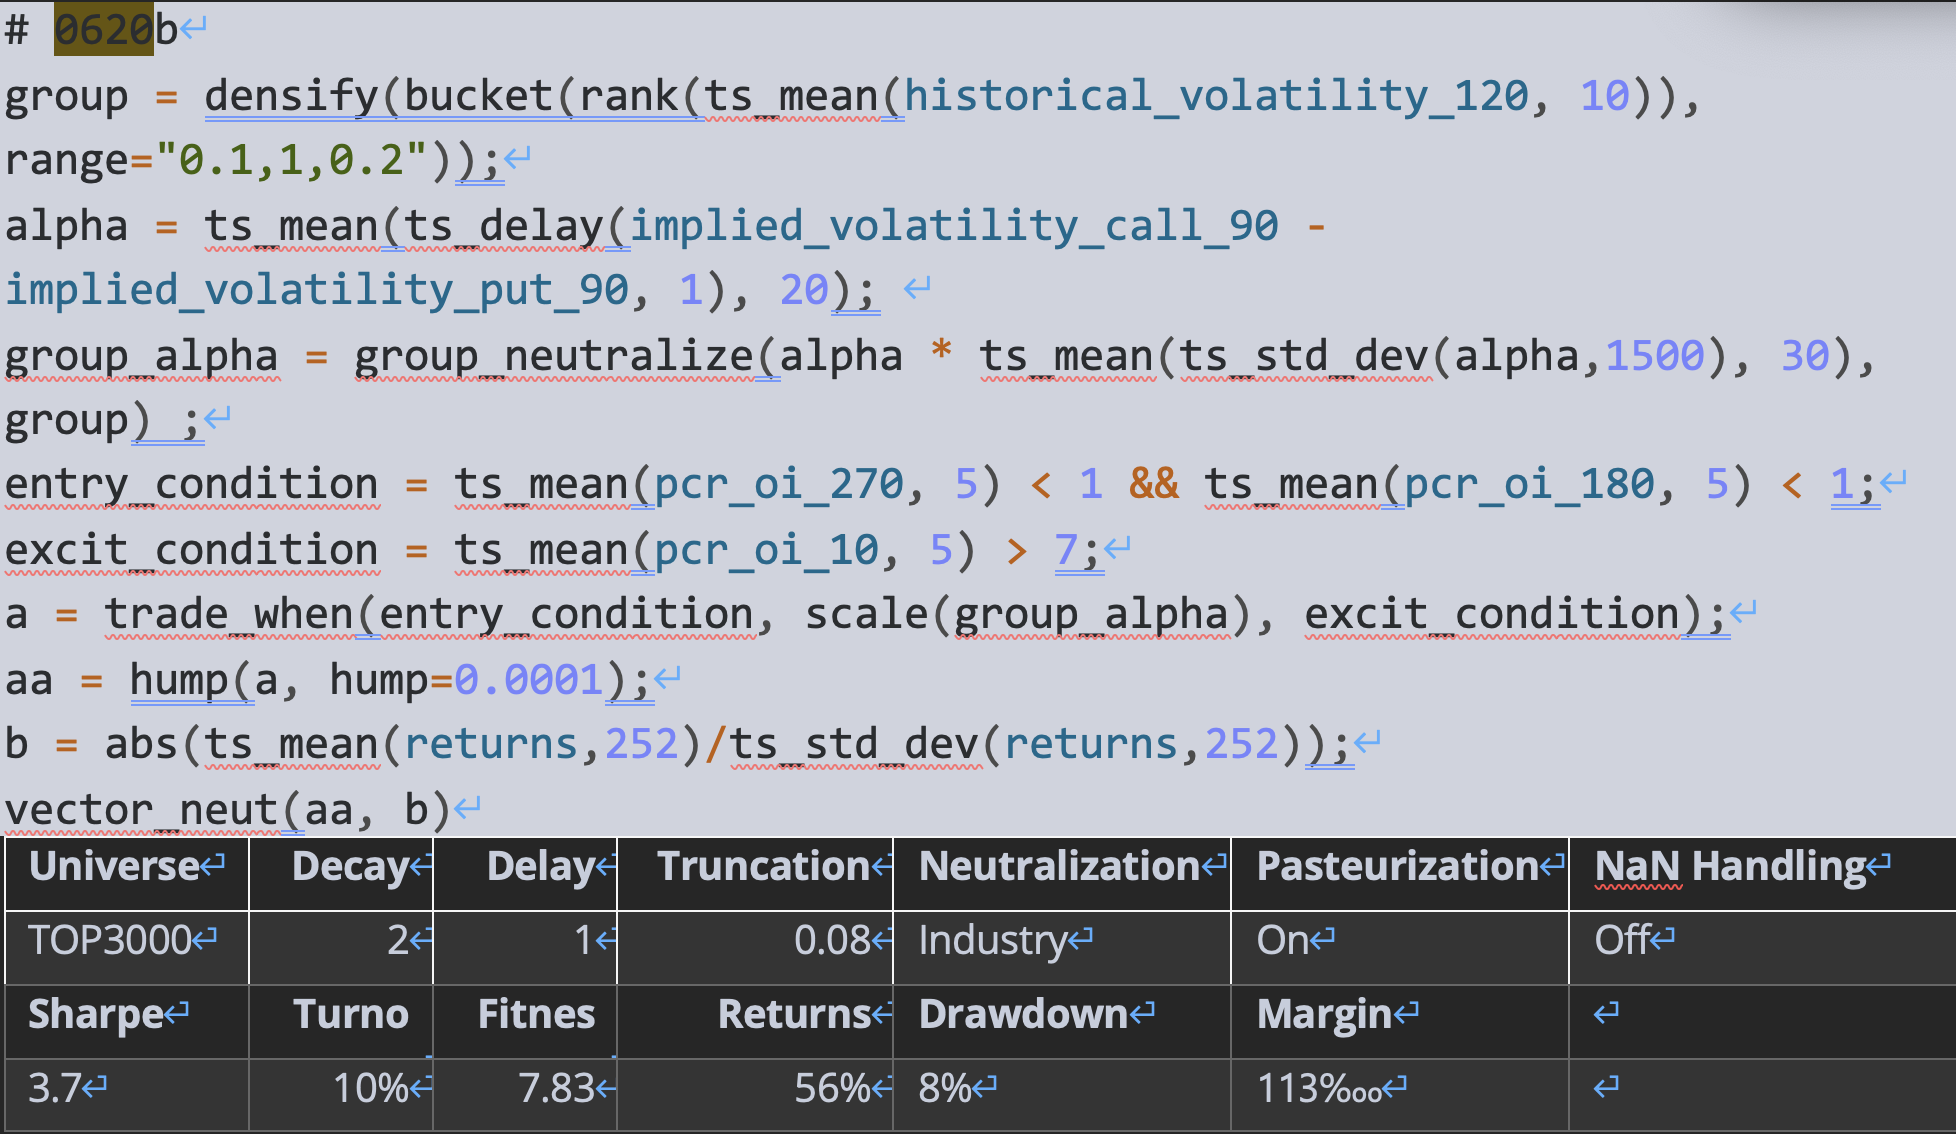

In [3]:
def alpha_0620b(
    historical_volatility_120,
    implied_volatility_call_90,
    implied_volatility_put_90,
    pcr_oi_270,
    pcr_oi_180,
    pcr_oi_10,
    returns,
):
  group = densify(bucket(rank(ts_mean(historical_volatility_120,10)),range='0.1,1,0.2'))
  alpha = ts_mean(ts_delay(implied_volatility_call_90 - implied_volatility_put_90,1),20)
  group_alpha = group_neutralize(alpha * ts_mean(ts_std_dev(alpha,1500),30),group)
  entry_condition = ts_mean(pcr_oi_270,5) < 1 & ts_mean(pcr_oi_180,5) < 1
  exit_condition = ts_mean(pcr_oi_10,5) > 7
  a = trade_when(entry_condition,scale(group_alpha),exit_condition)
  aa = hump(a,hump=0.0001)
  b = abs(ts_mean(returns,252)/ts_std_dev(returns,252))
  alpha_final = vector_neut(aa,b)
  return alpha_final

# Alpha2
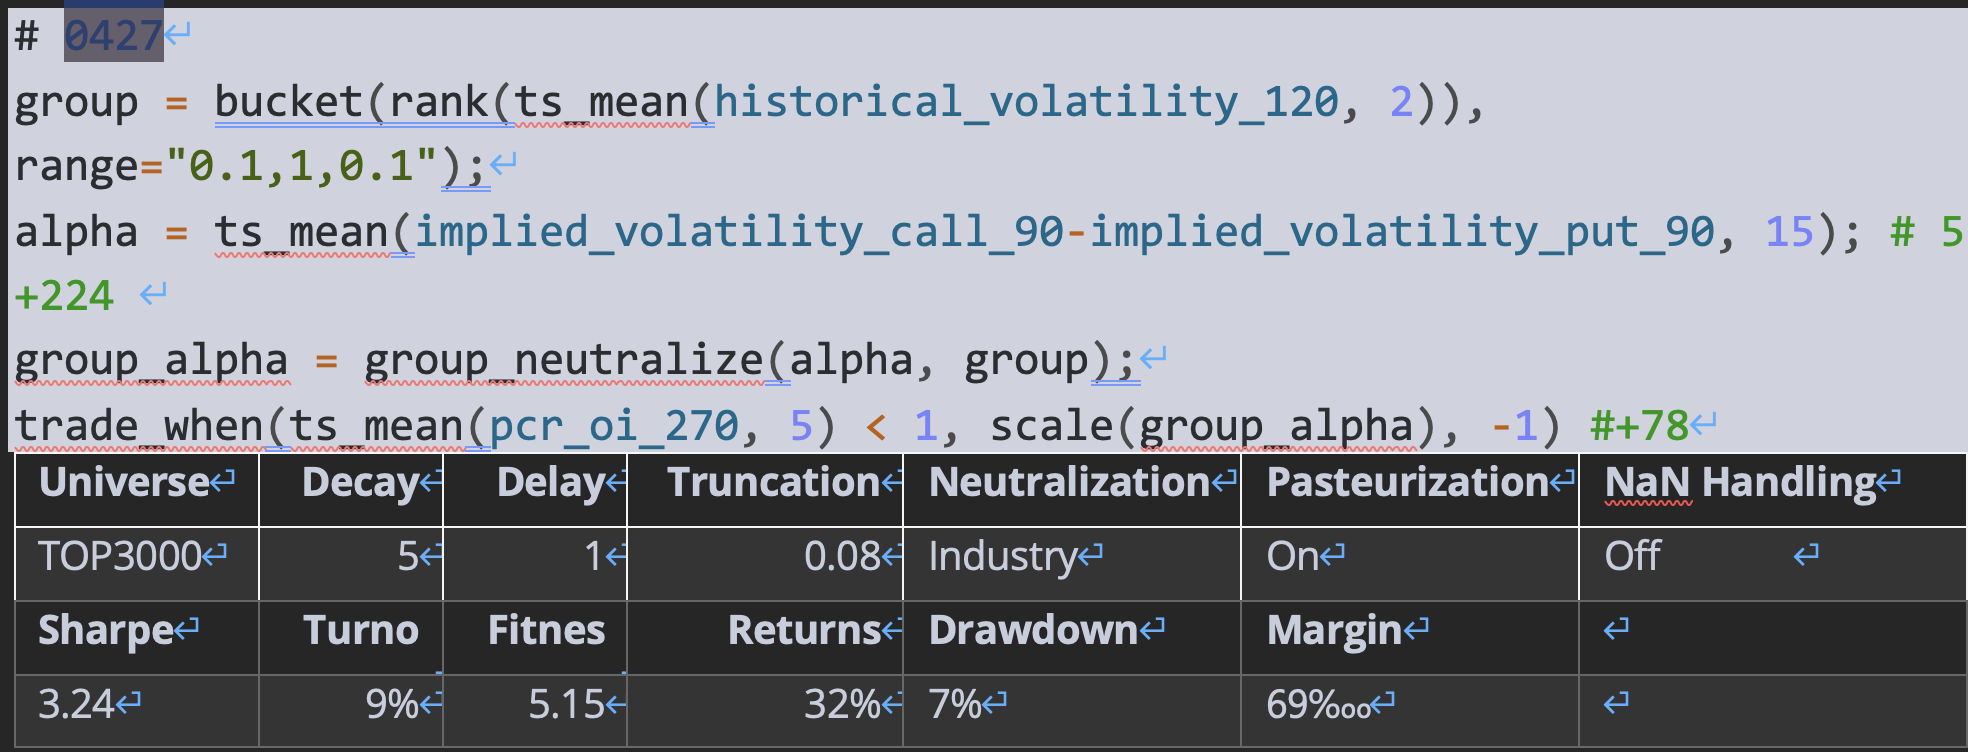

In [4]:
def alpha_0427(
    historical_volatility_120,
    implied_volatility_call_90,
    implied_volatility_put_90,
    pcr_oi_270,
):
  group = bucket(rank(ts_mean(historical_volatility_120,2)),range='0.1,1,0.1')
  alpha = ts_mean(implied_volatility_call_90 - implied_volatility_put_90,15)
  group_alpha = group_neutralize(alpha,group)
  alpha_final = trade_when(ts_mean(pcr_oi_270,5)<1,scale(group_alpha),-1)
  return alpha_final

# **Price-Volume**

# Alpha1
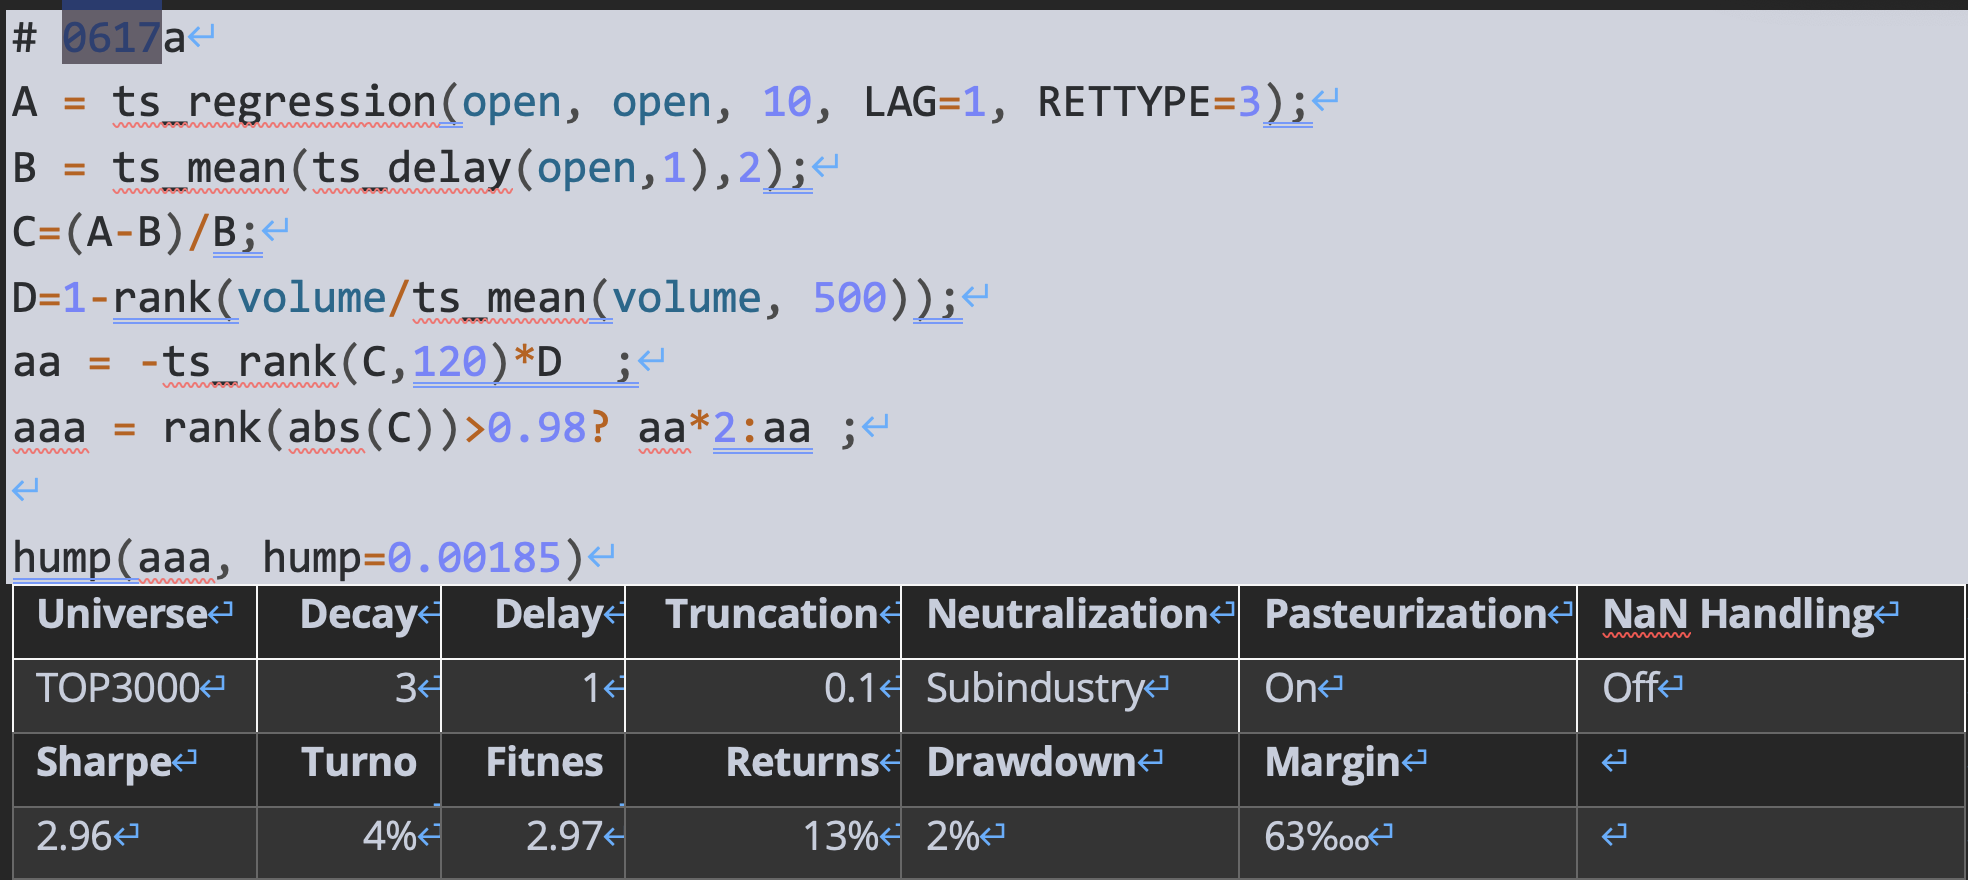

In [5]:
def alpha_0617a(
    open,
    volume
):
    A = ts_regression(open,open,window=5,lag=1,rettype=3)
    B = ts_mean(ts_delay(open,1),window=2)
    C = (A-B)/B
    D = 1 - rank(volume/ts_mean(volume,500))
    aa = -ts_rank(C,126)*D
    # if a stock is in top20% of |C| today, double its signal
    absC_rank = rank(C.abs())
    boost_mask = absC_rank > 0.98
    aaa = aa.where(~boost_mask , aa*3.0)
    alpha_final = hump(aaa,hump=0.0185)
    return alpha_final

# Alpha 2
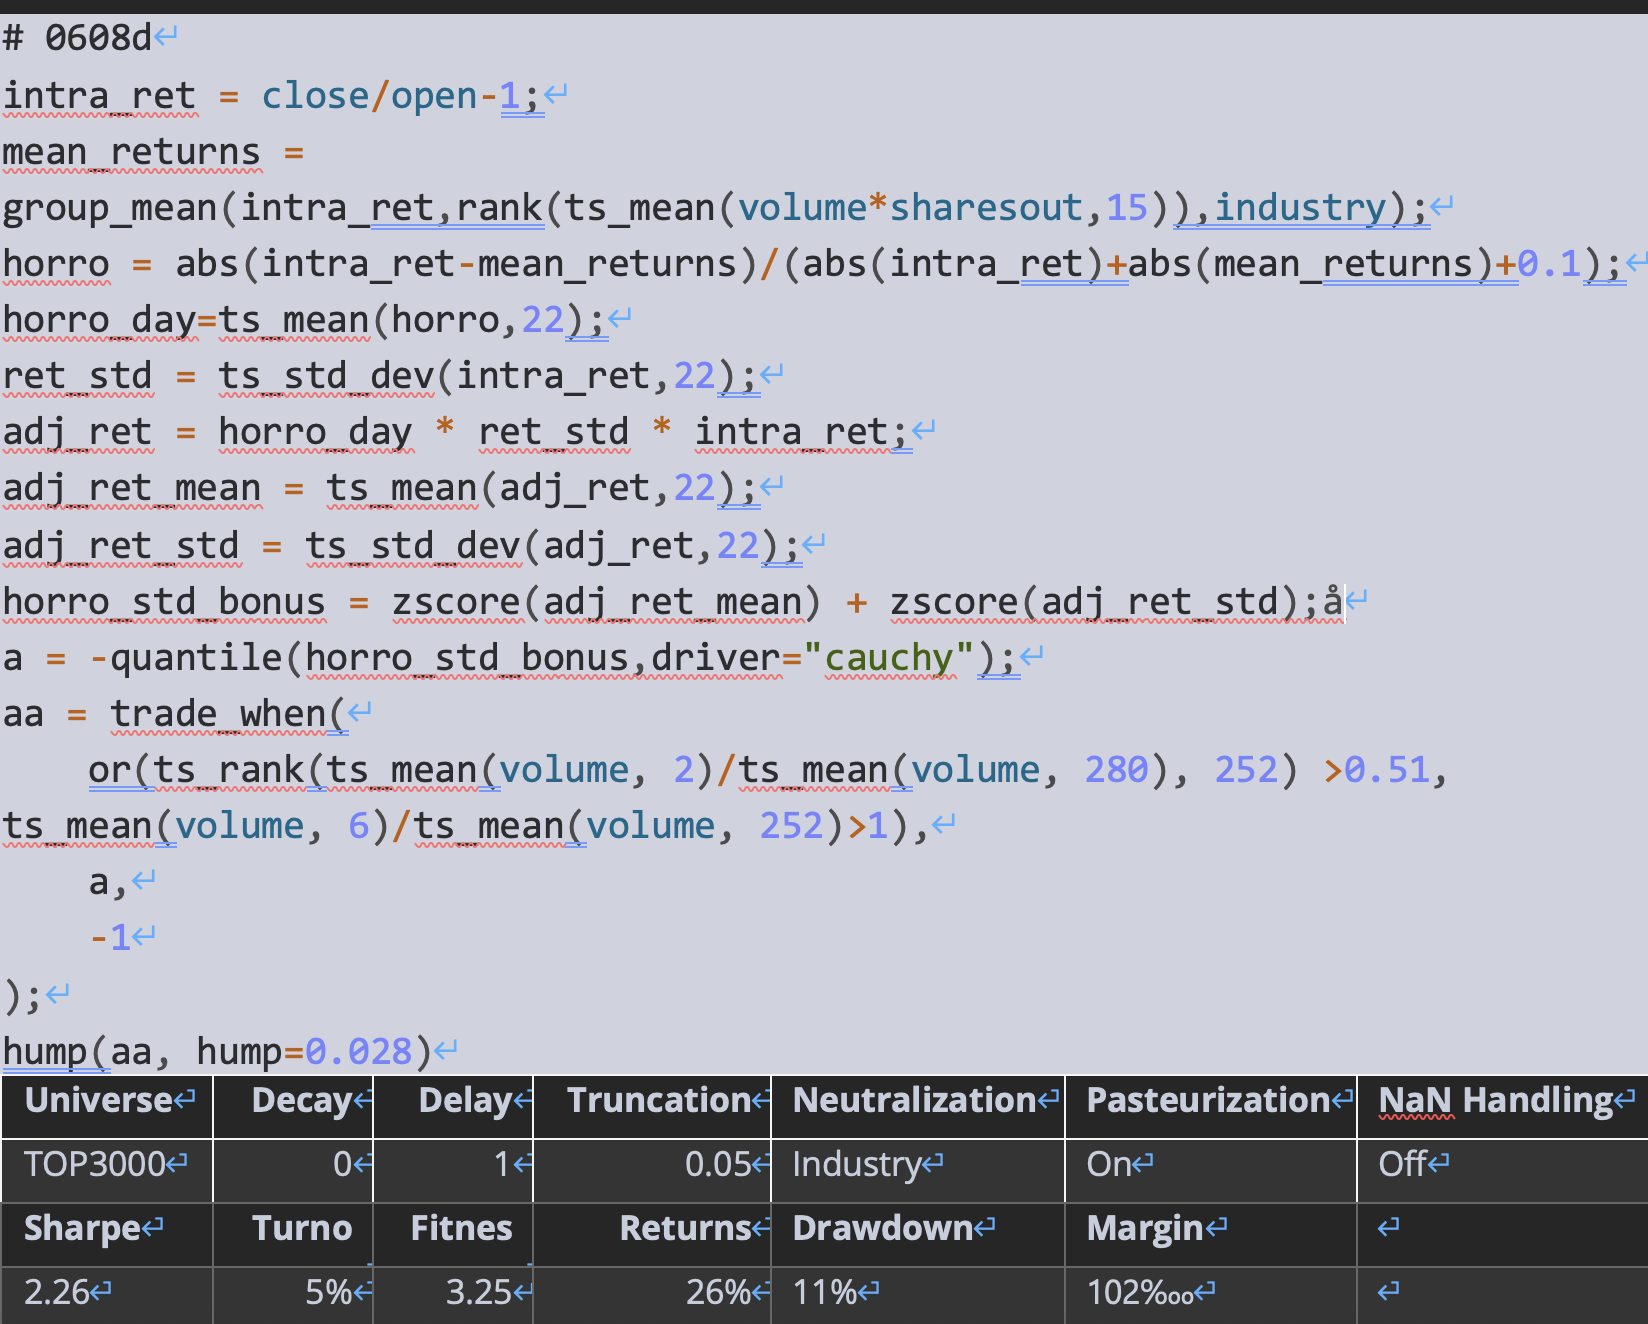

In [6]:
def alpha_0608d(
    close,
    open,
    volume,
    sharesout,
    industry,
    horro_window
):
    intra_ret = close/open - 1
    mean_returns = group_mean(intra_ret,rank(ts_mean(volume*sharesout,10)),industry)
    horro = abs(intra_ret-mean_returns)/(abs(intra_ret)+abs(mean_returns)+0.1)
    horro_day = ts_mean(horro,horro_window)
    ret_std = ts_std_dev(intra_ret,horro_window)
    adj_ret = horro_day*ret_std*intra_ret
    adj_ret_mean = ts_mean(adj_ret,horro_window) 
    adj_ret_std = ts_std_dev(adj_ret,horro_window)
    horro_std_bonus = zscore(adj_ret_mean) + zscore(adj_ret_std)
    a = -quantile_cauchy(horro_std_bonus,eps=1e-6)
    cond1 = ts_rank(ts_mean(volume,3)/ts_mean(volume,280),252) > 0.52
    cond2 = ts_mean(volume,3)/ts_mean(volume,252) > 1.01
    aa = a.where(cond1|cond2,-1.0)
    alpha_final = hump(aa,0.028)
    return alpha_final

# Alpha 3
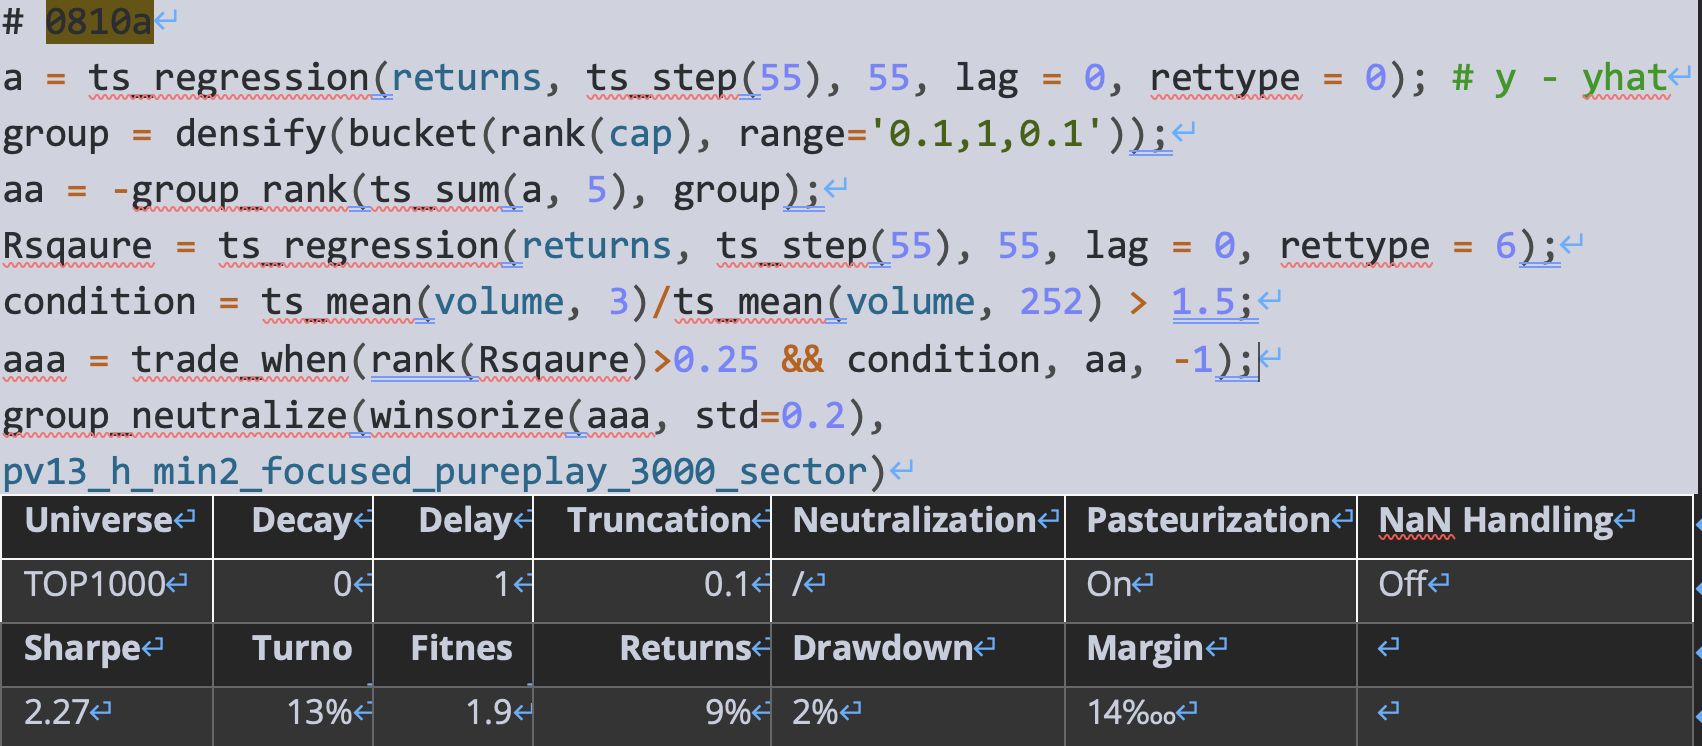

In [7]:
def alpha_0810a(
    returns,
    cap,
    volume,
): 
    a = ts_regression(returns,ts_step(returns),window=65,lag=0,rettype=0)
    group = densify(bucket(rank(cap), 0.0,1.0,0.2))
    aa = -group_rank(ts_sum(a,5),group)
    Rsquare = ts_regression(returns,ts_step(returns),window=65,lag=0,rettype=6)
    
    vol_short = ts_mean(volume, 2)
    vol_long  = ts_mean(volume, 252)
    # liquidity condition
    condition_liq = (vol_short / vol_long) > 2.0

    rsq_rank = rank(Rsquare)                 
    condition_r2 = rsq_rank > 0.45
    condition_liq = condition_liq.reindex_like(condition_r2)
    
    cond_values = np.logical_and(condition_liq.values, condition_r2.values)
    cond = pd.DataFrame(cond_values,
                    index=condition_r2.index,
                    columns=condition_r2.columns)
    aaa = trade_when_hold(cond,aa)
    alpha_final = winsorize(aaa,std=0.6)
    return alpha_final

# Alpha4 
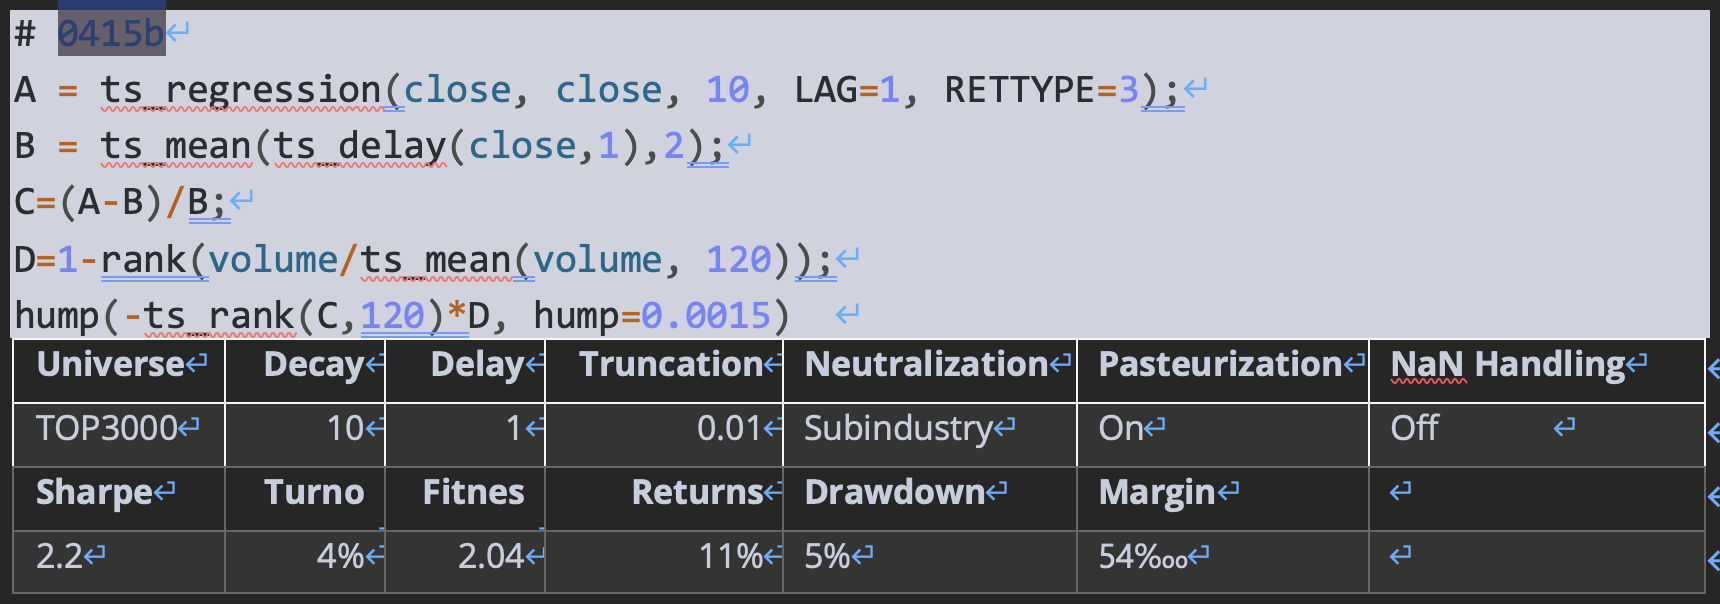

In [8]:
def alpha_0415b(
    close,
    volume
):
    A = ts_regression(close,close,window=5,lag=1,rettype=3)
    B = ts_mean(ts_delay(close,1),window=1)
    C = (A-B)/B
    D = 1 - rank(volume/ts_mean(volume,504))
    aa = -ts_rank(C,120)*D
    alpha_final = hump(aa,hump=0.00003)
    return alpha_final

# Alpha5
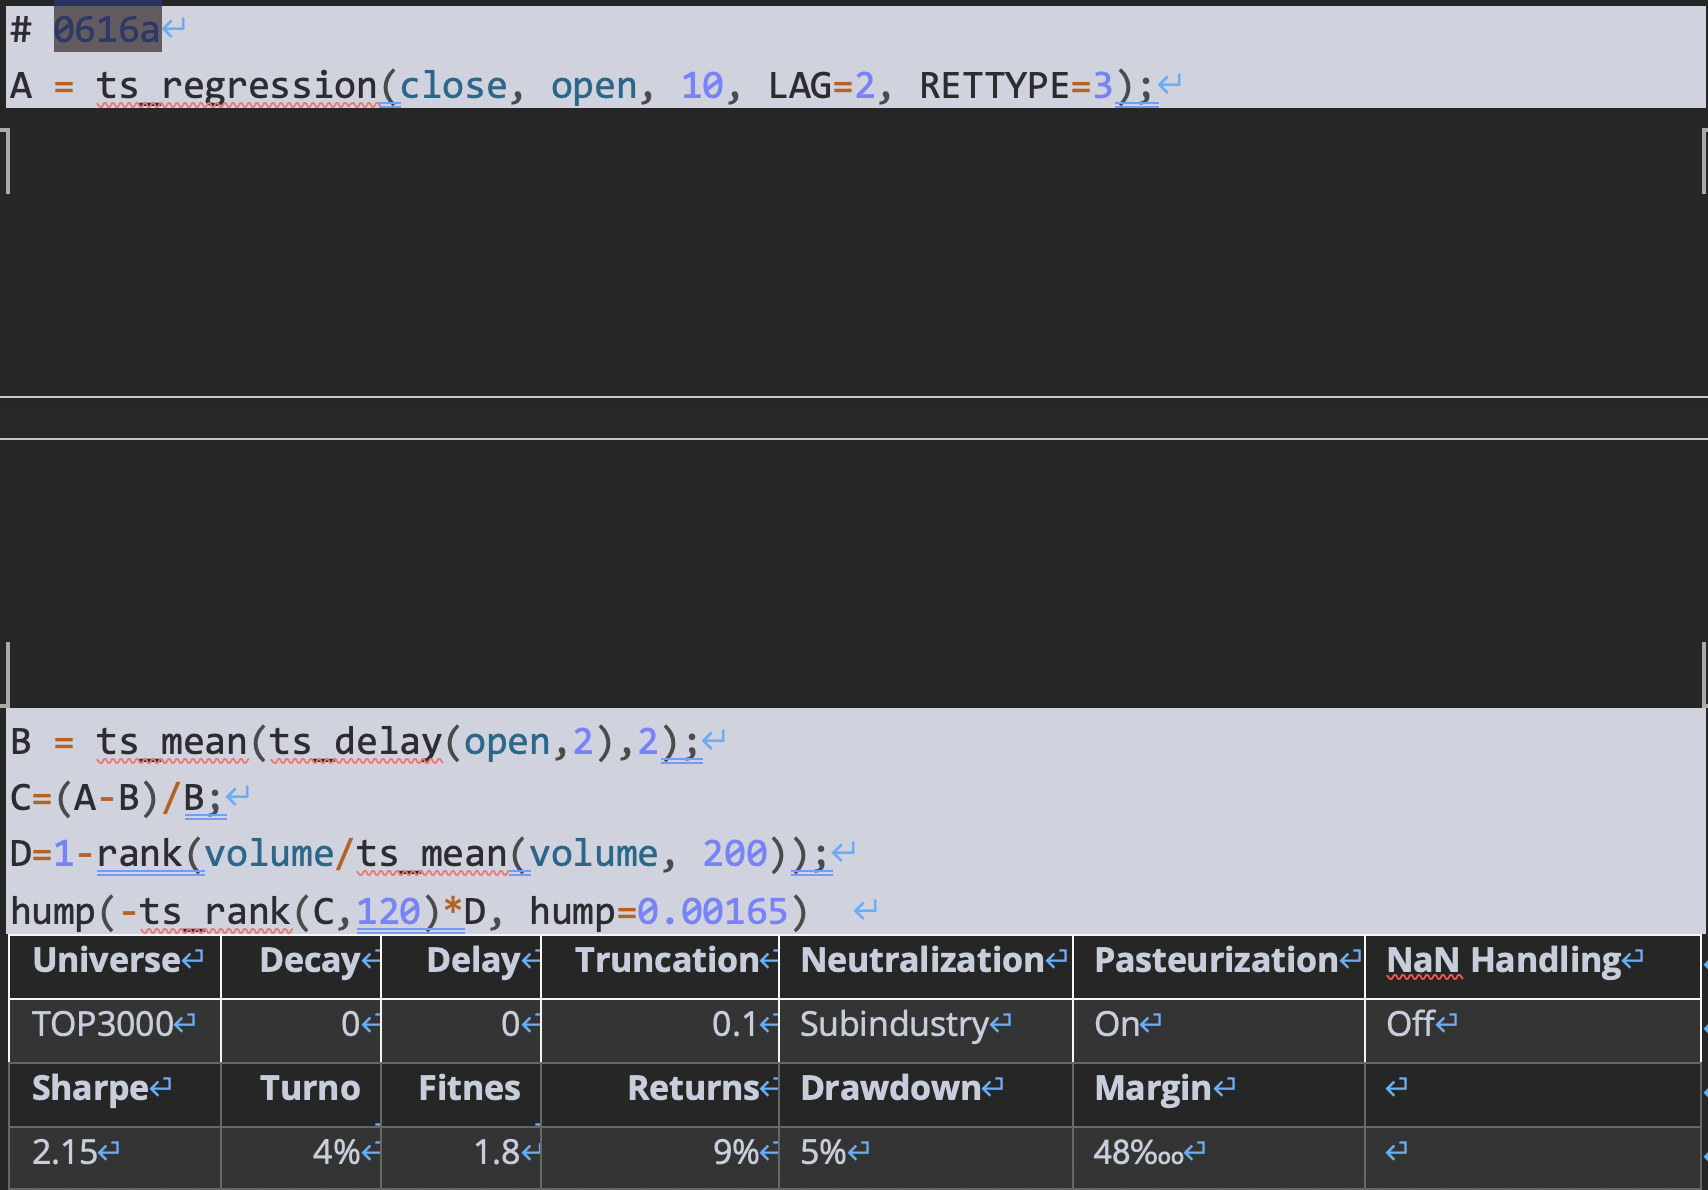

In [9]:
def alpha_0616a(
    close,
    open,
    volume
):
    A = ts_regression(close,open,window=20,lag=1,rettype=3)
    B = ts_mean(ts_delay(open,2),window=2)
    C = (A-B)/B
    D = 1 - rank(volume/ts_mean(volume,504))
    aa = -ts_rank(C,15)*D
    alpha_final = hump(aa,hump=0.0015)
    return alpha_final

# Alpha6
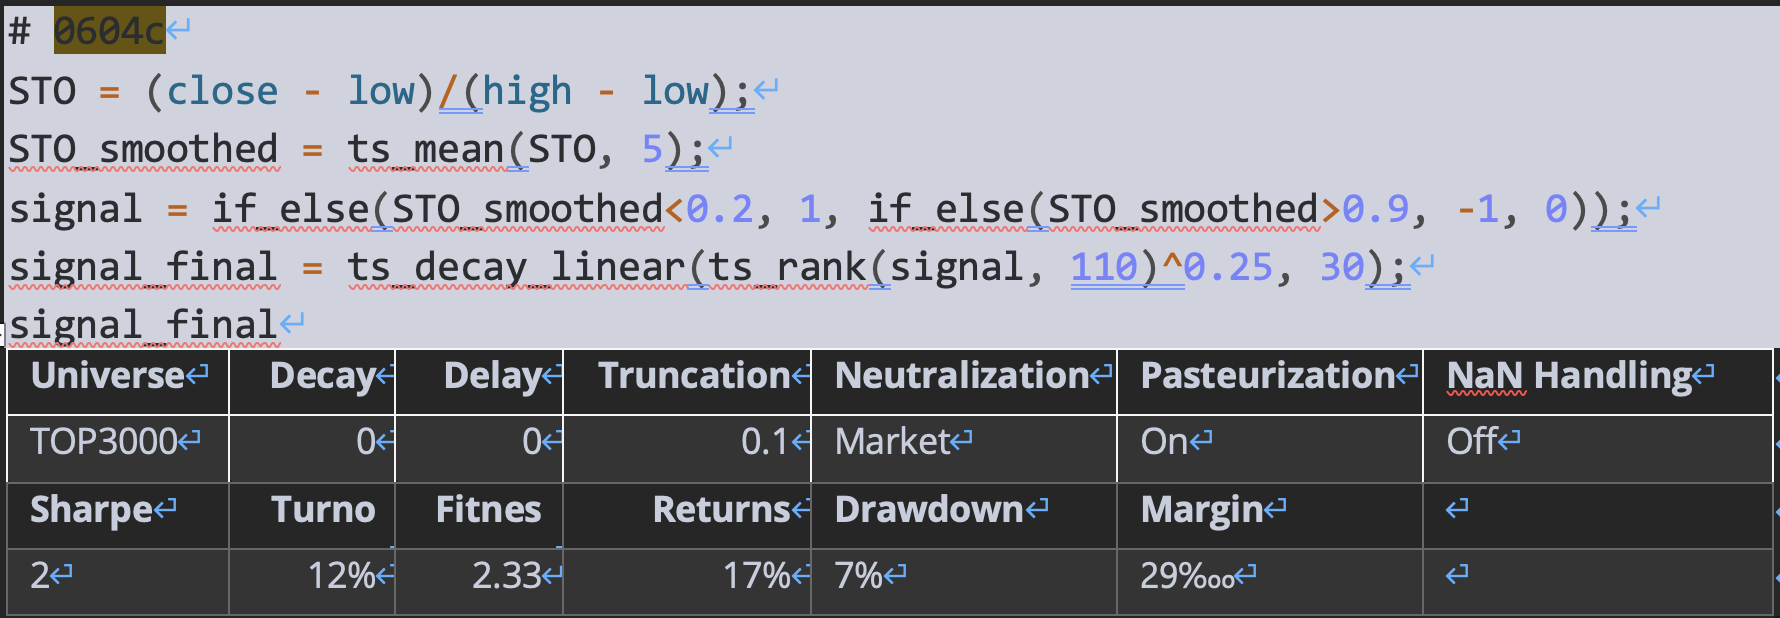

In [10]:
def alpha_0604c(
    close,
    high,
    low
):
    STO = (close-low)/(high-low)
    STO_smoothed = ts_mean(STO,6)
    signal = if_else(STO_smoothed<0.3,1,if_else(STO_smoothed>0.9,-1,0))
    alpha_final = ts_decay_linear(ts_rank(signal,110)**0.2,45)
    return alpha_final

# Alpha7 
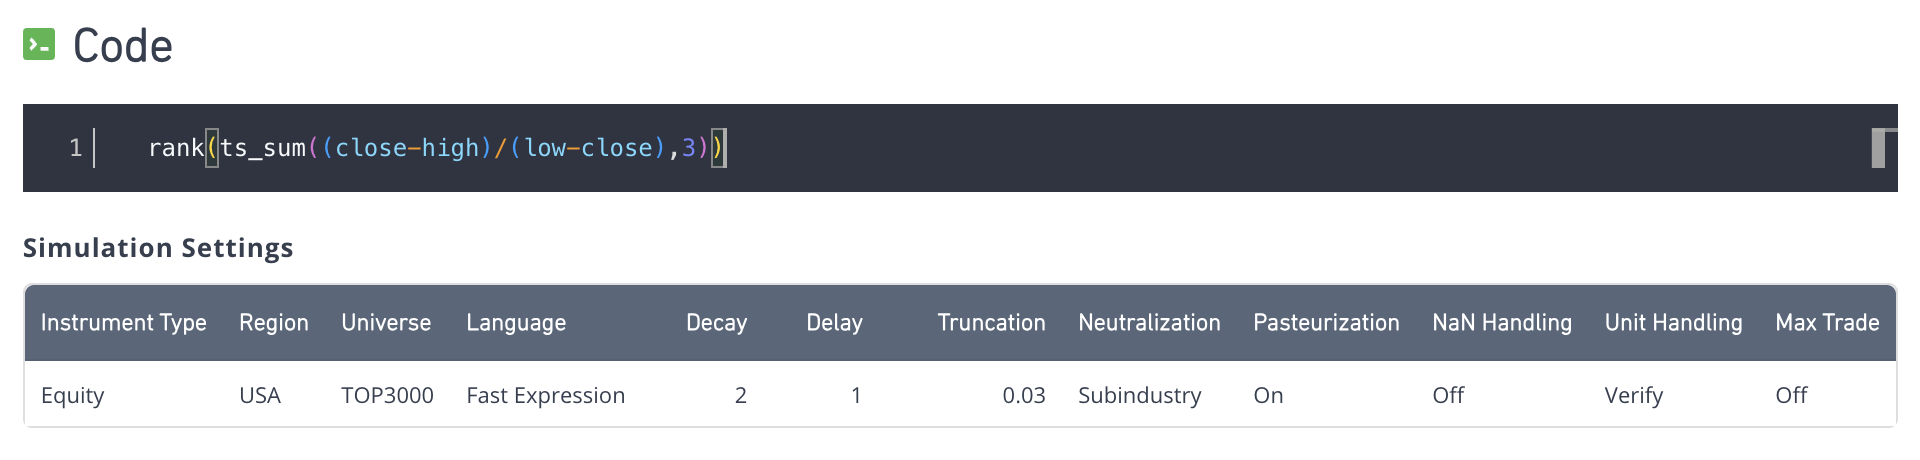

In [11]:
def alpha_0413a(
    close,
    high,
    low
):
    alpha_final = rank(ts_sum((close-high)/(low-close),1))
    return alpha_final

# Alpha8
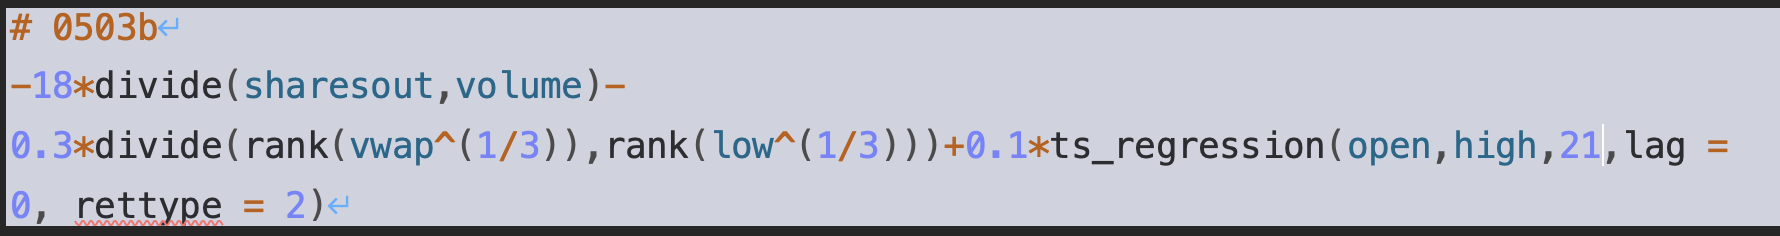

In [12]:
def alpha_0503b(
    sharesout,
    volume,
    vwap,
    low,
    open,
    high
):
    term1 = -18 * sharesout/volume
    term2 = 0.3 * rank(vwap**1/3)/rank(low**1/3)
    term3 = 0.1* ts_regression(open,high,21,lag=0,rettype=2)
    alpha_final = term1 - term2 + term3
    return alpha_final

# **Fundamentals**

# Alpha1
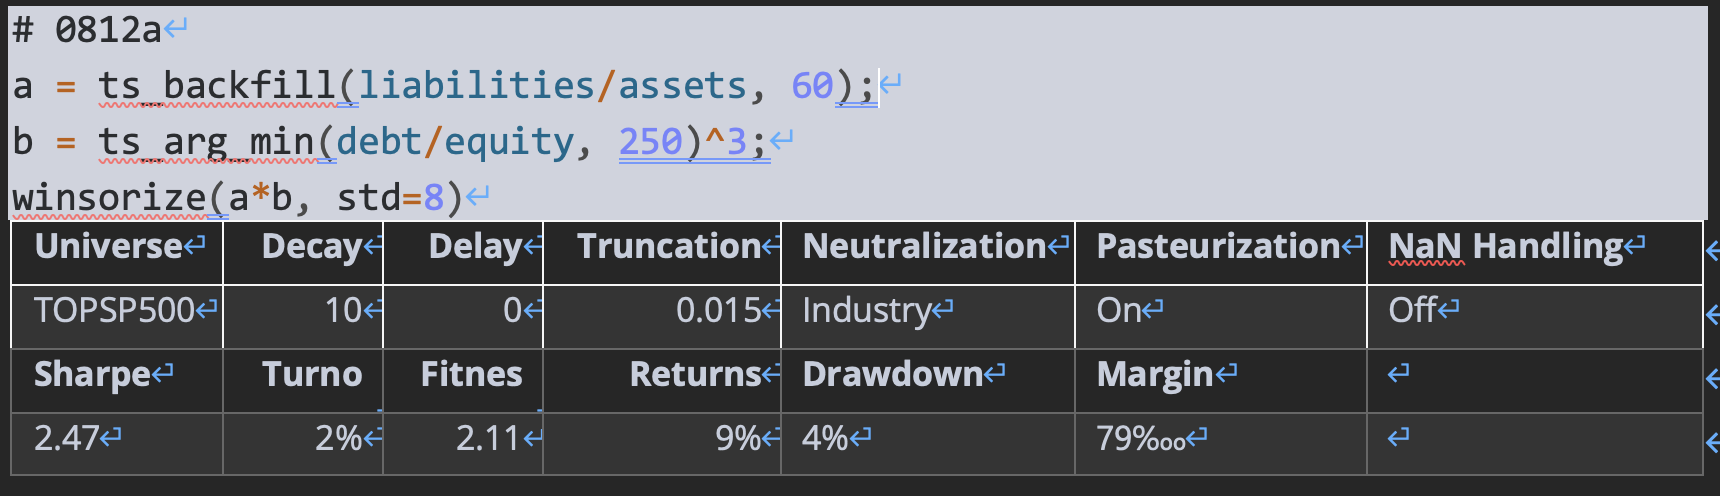

In [13]:
def alpha_0812a(
    liabilities,
    assets,
    debt,
    equity
):
    a = ts_backfill(liabilities/assets,120)
    b = ts_arg_min(debt/equity,504) ** 2
    alpha_final = winsorize(a*b,std=0.3)
    return alpha_final

# Alpha 2
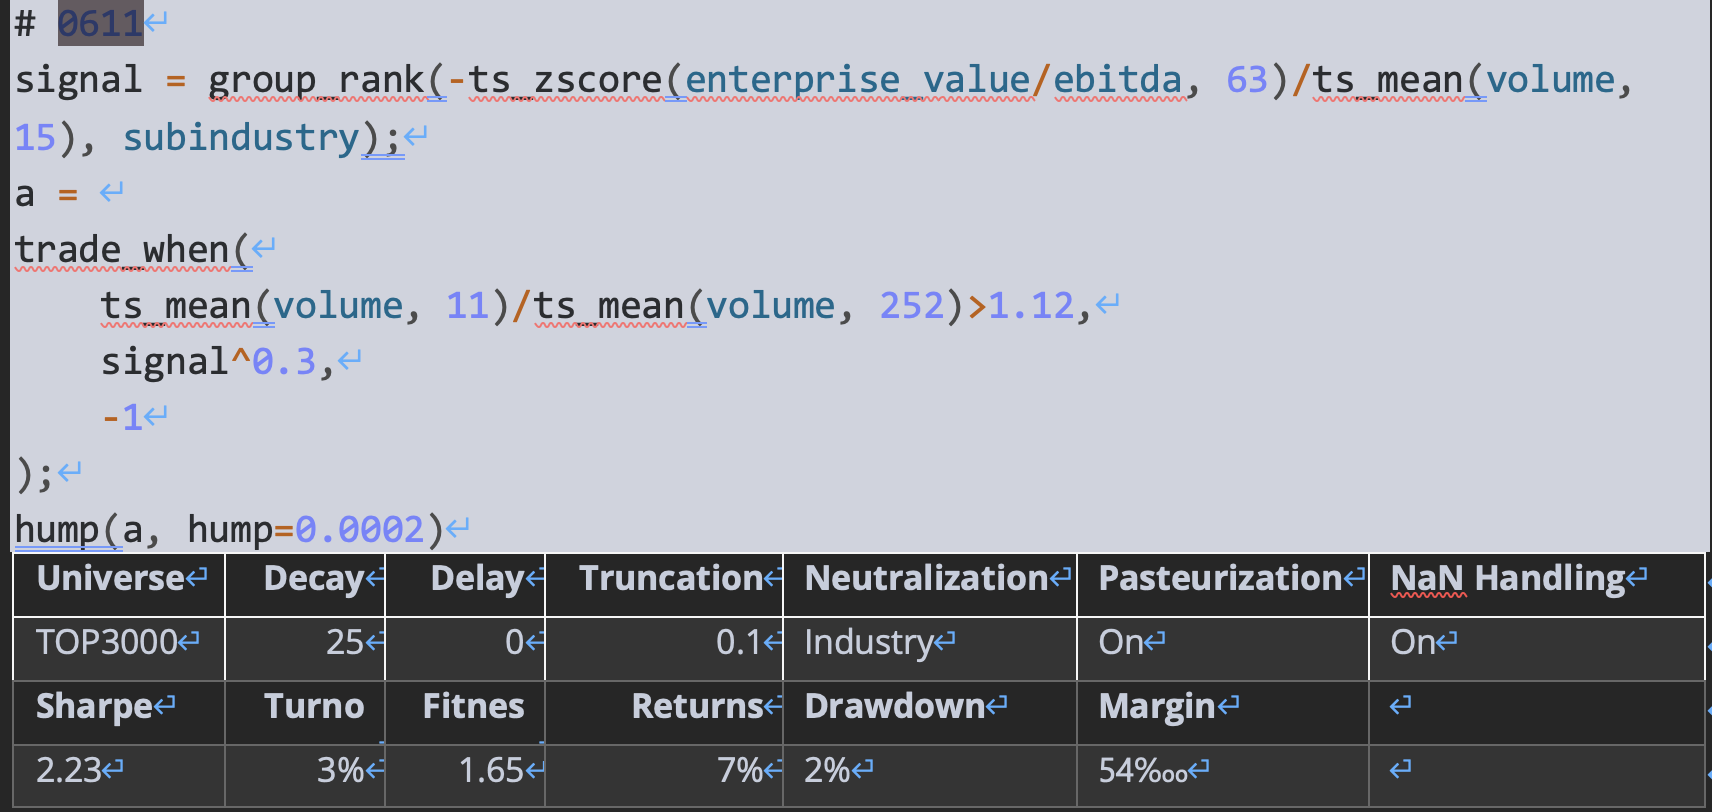

In [14]:
def alpha_0611(
    enterprise_value,
    ebitda,
    volume,
    subindustry,
):
    signal = group_rank(-ts_zscore(enterprise_value/ebitda,63)/ts_mean(volume,15),subindustry)
    base_signal = signal ** 0.3
    vol_11 = ts_mean(volume,11)
    vol_252 = ts_mean(volume,252)
    cond_liq = (vol_11/vol_252) > 1.12
    a = trade_when_hold(cond_liq,base_signal)
    alpha_final = hump(a,hump=0.0002)
    return alpha_final

# Alpha3
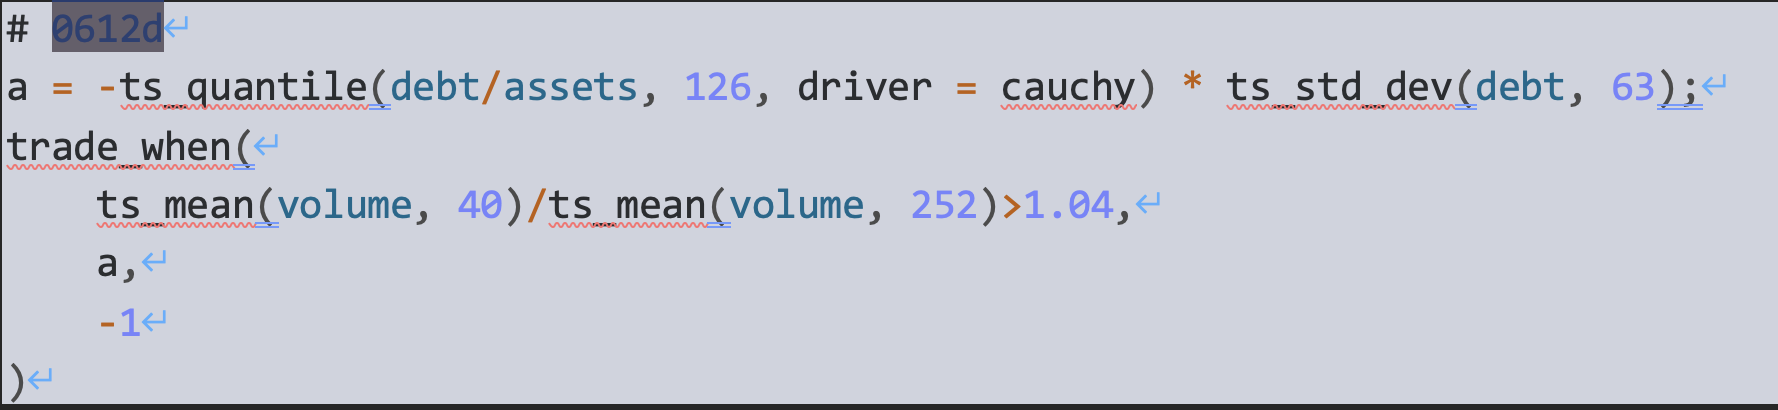

In [15]:
def alpha_0612d(
    debt,
    assets,
    volume
):
    a = -ts_quantile_cauchy(debt/assets,504)*ts_std_dev(debt,63)
    vol_40 = ts_mean(volume,40)
    vol_252 = ts_mean(volume,252)
    cond_liq = vol_40/vol_252 > 1.0
    alpha_final = trade_when_hold(cond_liq,a)
    return alpha_final

# Alpha4
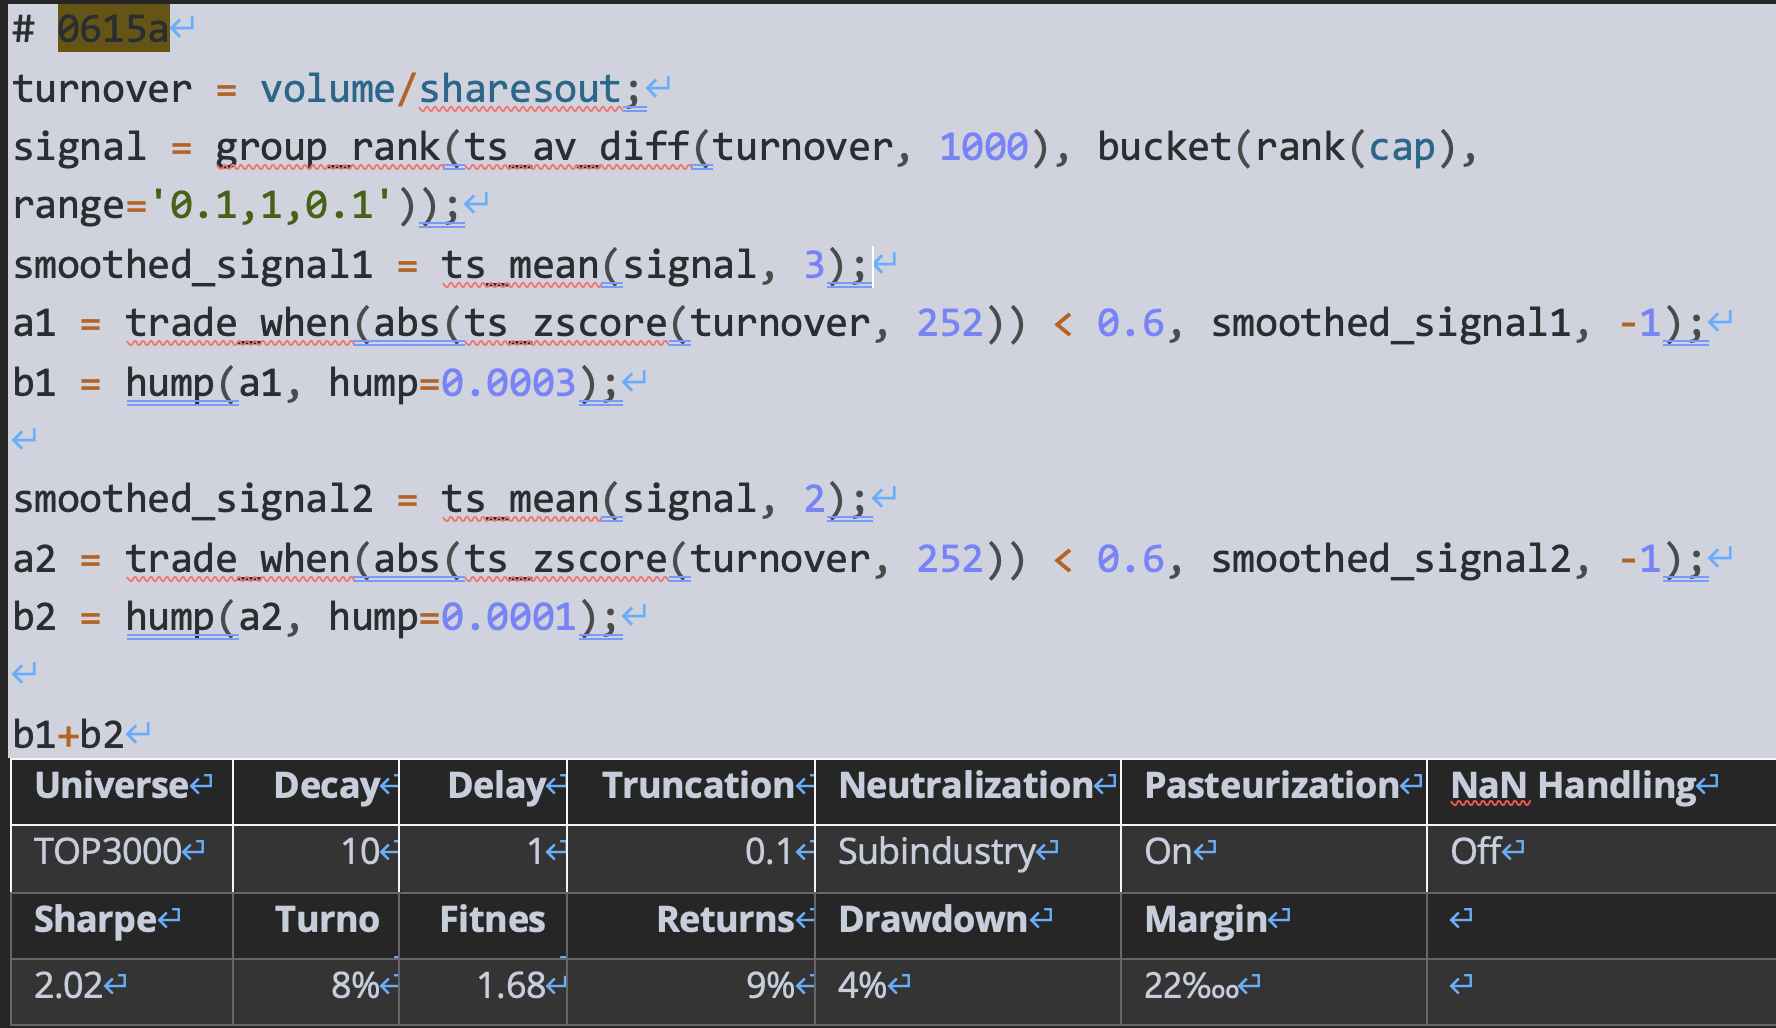

In [16]:
def alpha_0615a(
    volume,
    sharesout,
    cap
):
    turnover = volume/sharesout
    signal = group_rank(ts_av_diff(turnover,1008),bucket(rank(cap),0.0,1.0,0.2))
    smoothed_signal1 = ts_mean(signal,3)
    turnover_z = ts_zscore(turnover,252)
    cond = (turnover_z.abs()<0.3)
    a1 = trade_when_hold(cond,smoothed_signal1)
    b1 = hump(a1,hump=0.0003)

    smoothed_signal2 = ts_mean(signal,2)
    a2 = trade_when_hold(cond,smoothed_signal2)
    b2 = hump(a2,hump=0.0001)

    alpha_final = b1 + b2
    return alpha_final

# Alpha5
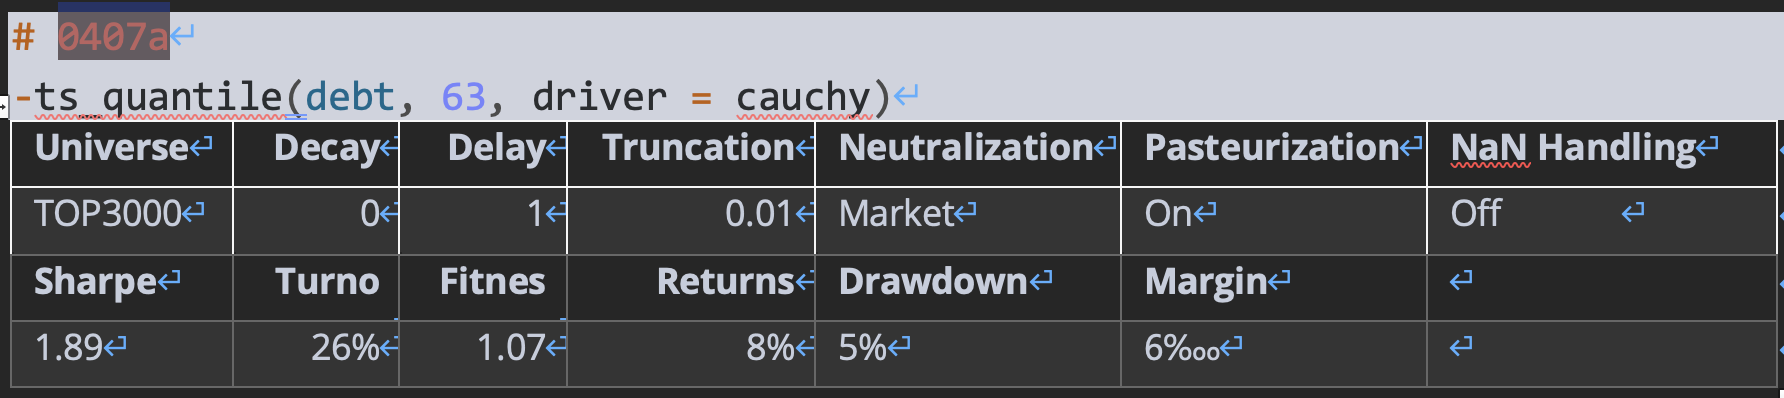

In [17]:
def alpha_0407a(
    debt
):
    alpha_final = -ts_quantile_cauchy(debt,window=22)
    return alpha_final

# Alpha6
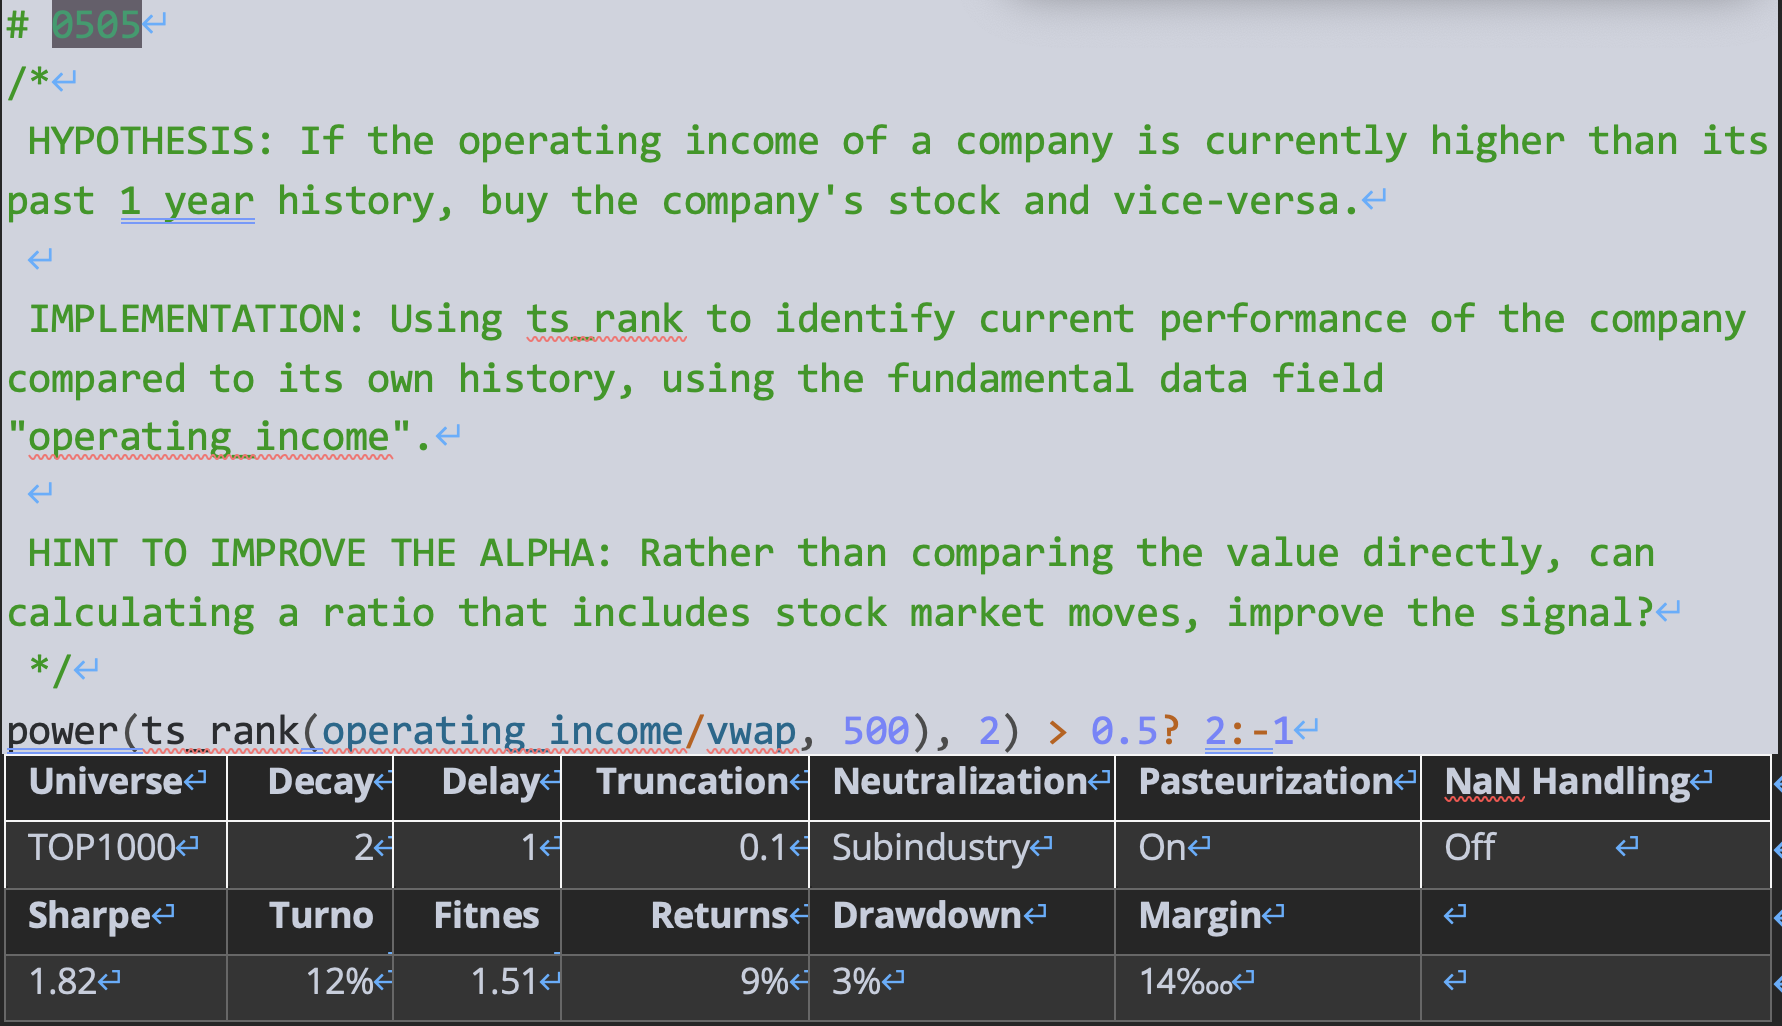

In [18]:
def alpha_0505(
    operating_income,
    vwap
):
    ratio = operating_income/vwap
    ranking = ts_rank(ratio,252)
    score = ranking ** 2
    cond = score > 0.9
    alpha_final = if_else(cond,2,-1)
    alpha_final = pd.DataFrame(alpha_final, index=ratio.index, columns=ratio.columns)
    return alpha_final

# Alpha7
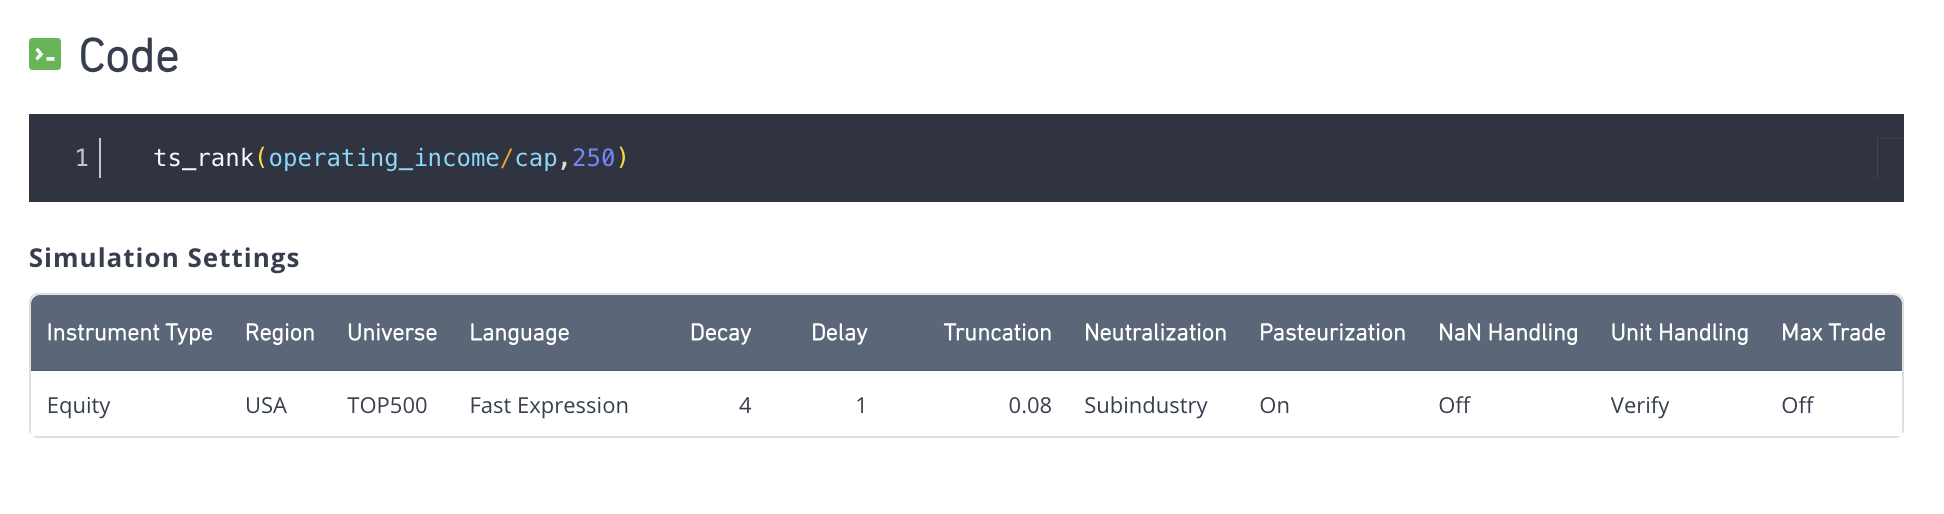

In [19]:
def alpha_0413b(
    operating_income,
    cap
):
    alpha_final = ts_rank(operating_income/cap,42)
    return alpha_final